# Interactive Plots
v.ekc

Static plots are great for reports but interactive plots let the reader *explore* the data themselves. Today we cover Plotly Express for hover/animation and ipywidgets for sliders and dropdowns.

| Section | Topic |
|---------|-------|
| 1 | Setup |
| 2 | Plotly Express:  Basic Interactivity |
| 3 | ipywidgets: Sliders and Dropdowns |
| 4 | Combining Widgets with Plotly |
| 5 | Animations with Plotly: Gapminder |
| 6 | 🔬 Open Exploration: Gapminder |
| Appendix | Quick Reference |

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

---
## 2. Plotly Express: Basic Interactivity

Plotly Express gives you hover, zoom, and pan for free — just swap `sns` for `px`.

### 

| Function | What it does |
|----------|--------------|
| `px.line(x=, y=)` | Interactive line plot |
| `px.scatter(df, x=, y=, color=)` | Interactive scatter plot |
| `px.histogram(df, x=)` | Interactive histogram |
| `px.imshow(matrix)` | Heatmap (e.g., correlation matrix) |
| `hover_data=[...]` | Add extra columns to hover tooltip |
| `hover_name='col'` | Bold label at top of tooltip |
| `facet_col='col'` | Small multiples by column value |
| `fig.show()` | Render the plot |

In [2]:
# Import plotly express
import plotly.express as px

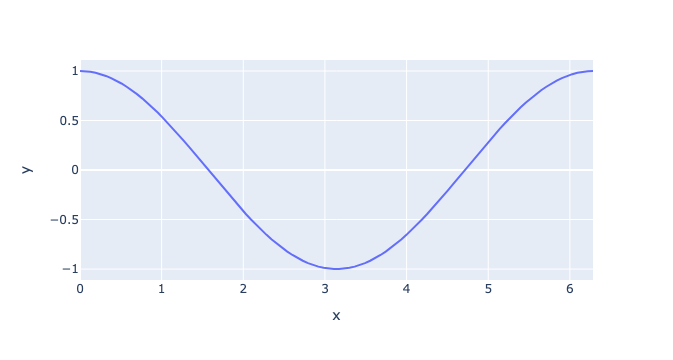

In [3]:
# Create a basic line plot
t = np.linspace(0, 2*np.pi, 100)
fig = px.line(x=t, y=np.cos(t))
fig.show()

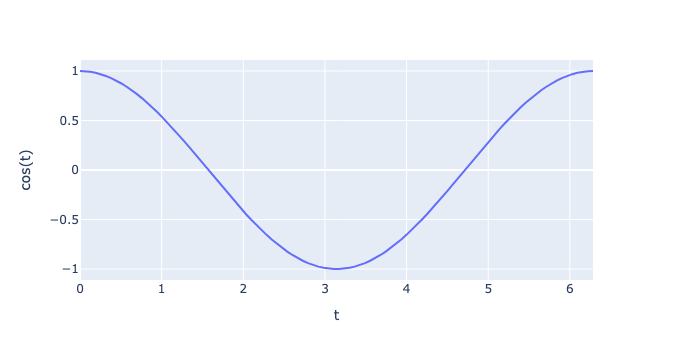

In [4]:
# Include more details in the hover feature
fig = px.line(x=t, y=np.cos(t), labels={'x':'t', 'y':'cos(t)'})
fig.show()

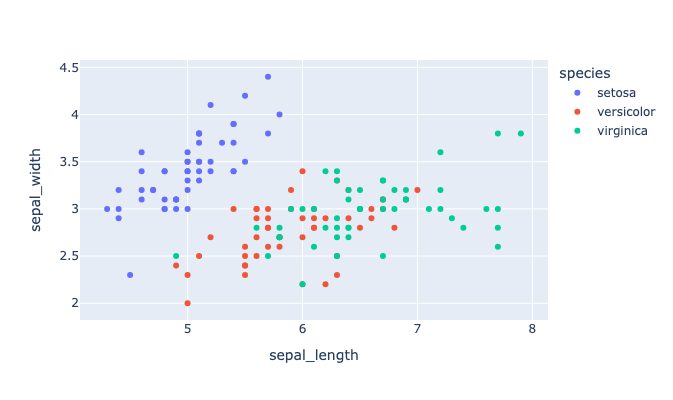

In [7]:
# Simple scatter plot
df = px.data.iris() # plotly has some built in datasets (like seaborn and plotnine)

fig = px.scatter(df, x="sepal_length", y="sepal_width",color='species', width=500, height=400)
fig.show()

In [8]:
# What other info is in the dataframe?
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


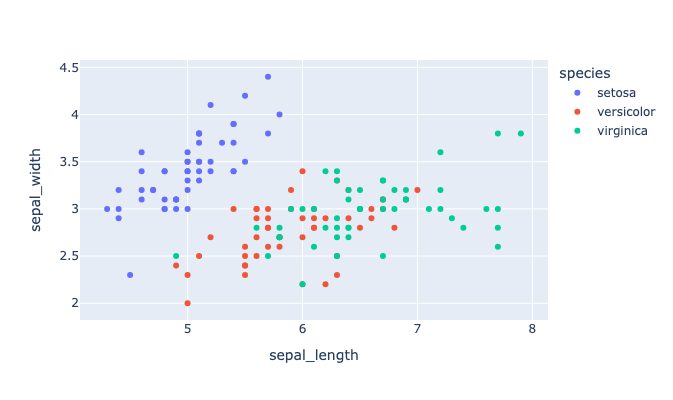

In [9]:
# add more data to the hover feature
fig = px.scatter(df, x="sepal_length", y="sepal_width",color='species',
                 width=500, height=400,
                hover_data=['petal_length','petal_width'])
fig.show()

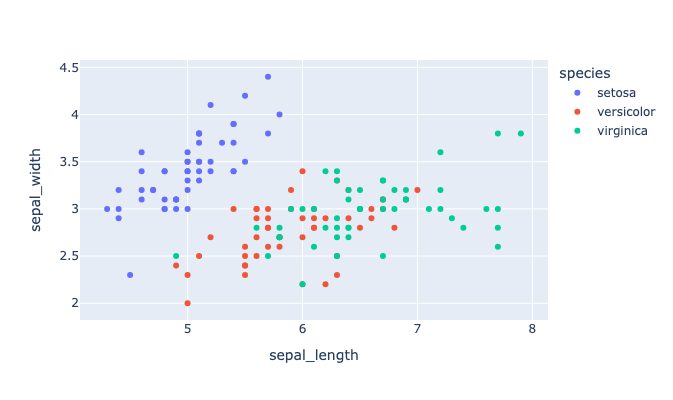

In [10]:
# add more data to the hover feature
fig = px.scatter(df, x="sepal_length", y="sepal_width",color='species',
                 width=500, height=400,
                hover_data=['petal_length','petal_width'],hover_name='species_id')
fig.show()

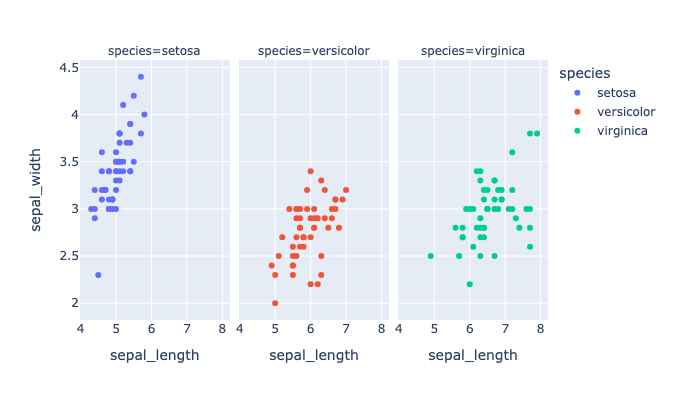

In [11]:
# Facetting is also possible
fig = px.scatter(df, x="sepal_length", y="sepal_width",color='species',
                 width=1000, height=400,
                hover_data=['petal_length','petal_width'],
                facet_col='species')
fig.show()

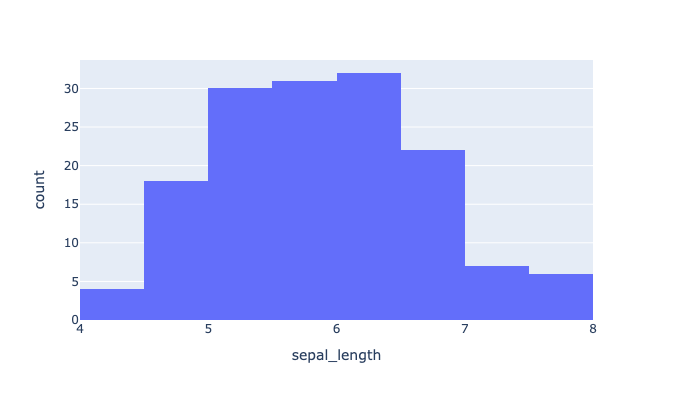

In [12]:
# Histograms
fig = px.histogram(df, x="sepal_length", 
                 width=500, height=400)
fig.show()

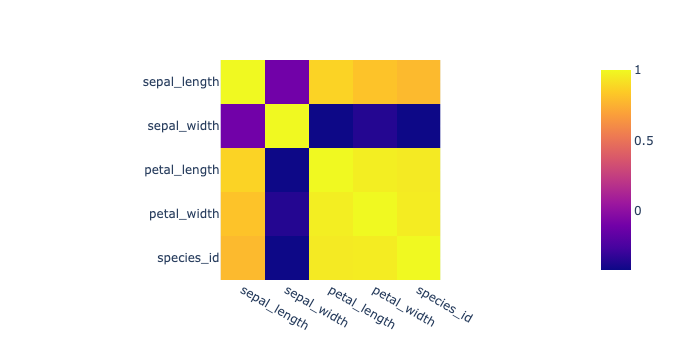

In [14]:
# Create heatmap using Plotly Express
fig = px.imshow(
  df.corr(numeric_only=True),
    color_continuous_scale='plasma'
)

# Show plot
fig.show()

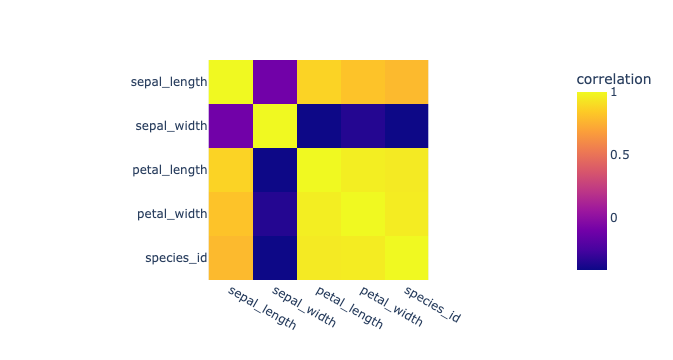

In [15]:
# Give a more descriptive name
fig = px.imshow(
  df.corr(numeric_only=True),
    color_continuous_scale='plasma',
    labels={'color':'correlation'}
)

# Show plot
fig.show()

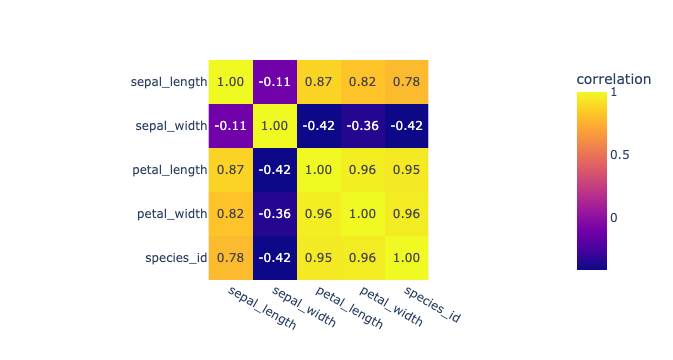

In [16]:
# Add correlation to the plot
fig = px.imshow(
  df.corr(numeric_only=True),
    color_continuous_scale='plasma',
    labels={'color':'correlation'},
    text_auto='.2f'
)

# Show plot
fig.show()

---
## 3. ipywidgets: Sliders and Dropdowns

`ipywidgets` adds interactive controls to notebooks — connect them to any function with `interact()`.

### 📋 Board Reference

| Widget | Code | Use case |
|--------|------|----------|
| Integer slider | `widgets.IntSlider()` | Discrete integer values |
| Float slider | `widgets.FloatSlider(value=, min=, max=, step=)` | Continuous values |
| Dropdown | `widgets.Dropdown(options=[...], description='Label:')` | Categorical choices |
| Dict dropdown | `widgets.Dropdown(options={'label': value})` | Human-readable labels |
| Connect to function | `interact(func, param=widget)` | Re-runs function on change |

In [17]:
from ipywidgets import interact
import ipywidgets as widgets

In [18]:
# Write a function
def cube(x):
    return x**3

In [19]:
# Adjusting the input of the function by interacting
interact(cube, x = 3);

interactive(children=(IntSlider(value=3, description='x', max=9, min=-3), Output()), _dom_classes=('widget-int…

### Customizing sliders

In [20]:
# A simple integer slider 
widgets.IntSlider()

IntSlider(value=0)

In [21]:
# A simple float slider
widgets.FloatSlider()

FloatSlider(value=0.0)

In [22]:
# Customize your slider
widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description = 'My slider')

FloatSlider(value=1.0, description='My slider', max=2.0, min=0.1)

In [39]:
# Sliders for understanding functions
def sin_func(frequency):
    x = np.linspace(0, 10, 100)
    plt.plot(x, np.sin(frequency * x))
    plt.xlabel('x')
    plt.ylabel('sin(f*x)')
    plt.show()

# Create a slider widget using widget.FloatSlider
slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=2.0,
    step=0.1,
    description='f:'
)

# Use interact to connect the slider and the update_plot function
interact(sin_func, frequency=slider);

interactive(children=(FloatSlider(value=1.0, description='f:', max=2.0, min=0.1), Output()), _dom_classes=('wi…

#### my widget

In [32]:
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display

# starting info
starting_stitches = 68
ending_stitches = 44
total_rows = 90

# decrease rows based on alternating 7, 8 rows
decrease_rows = [7, 15, 22, 30, 37, 45, 52, 60, 67, 75, 82, 90]

def sleeve_tracker(row):
    # count how many decrease rows have happened up to this row
    decreases_done = sum(1 for r in decrease_rows if r <= row)
    current_stitches = starting_stitches - 2 * decreases_done
    
    print(f"Row: {row}")
    print(f"Current stitches in the round: {current_stitches}")
    
    if row in decrease_rows:
        print("Decrease row: YES (-2 stitches)")
    else:
        print("Decrease row: No")
    
    # optional: show next decrease row
    next_dec = next((r for r in decrease_rows if r > row), None)
    if next_dec:
        print(f"Next decrease row: {next_dec}")
    else:
        print("All decreases completed!")

interact(sleeve_tracker, row=widgets.IntSlider(min=1,
                                               max=total_rows,
                                               step=1,
                                               value=1,
                                              layout=widgets.Layout(width='800px')));


interactive(children=(IntSlider(value=1, description='row', layout=Layout(width='800px'), max=90, min=1), Outp…

In [43]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go

# starting info
starting_stitches = 68
total_rows = 90
decrease_rows = [7, 15, 22, 30, 37, 45, 52, 60, 67, 75, 82, 90]

# compute stitch count for every row
rows = list(range(1, total_rows + 1))
stitch_counts = []

for row in rows:
    decreases_done = sum(1 for r in decrease_rows if r <= row)
    current_stitches = starting_stitches - 2 * decreases_done
    stitch_counts.append(current_stitches)

# state
current_row = 1

# output areas
text_output = widgets.Output()
plot_output = widgets.Output()

def sleeve_tracker(row):
    decreases_done = sum(1 for r in decrease_rows if r <= row)
    current_stitches = starting_stitches - 2 * decreases_done

    print(f"Row: {row} / {total_rows}")
    print(f"Current stitches in the round: {current_stitches}")

    if row in decrease_rows:
        print("Decrease row: YES (-2 stitches)")
    else:
        print("Decrease row: No")

    next_dec = next((r for r in decrease_rows if r > row), None)
    if next_dec:
        print(f"Next decrease row: {next_dec}")
    else:
        print("All decreases completed!")

def make_plot(row):
    current_stitches = stitch_counts[row - 1]

    # decrease row values
    dec_y = [stitch_counts[r - 1] for r in decrease_rows]

    fig = go.Figure()

    # main stitch-count line
    fig.add_trace(go.Scatter(
        x=rows,
        y=stitch_counts,
        mode='lines+markers',
        name='Stitch count',
        hovertemplate='Row %{x}<br>Stitches %{y}<extra></extra>'
    ))

    # highlight decrease rows
    fig.add_trace(go.Scatter(
        x=decrease_rows,
        y=dec_y,
        mode='markers',
        name='Decrease rows',
        marker=dict(size=10, symbol='diamond'),
        hovertemplate='Decrease row %{x}<br>Stitches %{y}<extra></extra>'
    ))

    # current row marker
    fig.add_trace(go.Scatter(
        x=[row],
        y=[current_stitches],
        mode='markers',
        name='Current row',
        marker=dict(size=16, symbol='circle'),
        hovertemplate='Current row %{x}<br>Stitches %{y}<extra></extra>'
    ))

    fig.update_layout(
        title='Sleeve Stitch Count by Row',
        xaxis_title='Row',
        yaxis_title='Stitches in the round',
        width=900,
        height=500,
        hovermode='x unified'
    )

    return fig

def update_display():
    with text_output:
        clear_output()
        sleeve_tracker(current_row)

    with plot_output:
        clear_output(wait=True)
        fig = make_plot(current_row)
        fig.show()

# buttons
next_button = widgets.Button(description="Next Row")
prev_button = widgets.Button(description="Previous Row")
reset_button = widgets.Button(description="Reset")

def on_next_clicked(b):
    global current_row
    if current_row < total_rows:
        current_row += 1
    update_display()

def on_prev_clicked(b):
    global current_row
    if current_row > 1:
        current_row -= 1
    update_display()

def on_reset_clicked(b):
    global current_row
    current_row = 1
    update_display()

next_button.on_click(on_next_clicked)
prev_button.on_click(on_prev_clicked)
reset_button.on_click(on_reset_clicked)

buttons = widgets.HBox([prev_button, next_button, reset_button])

display(buttons, text_output, plot_output)
update_display()

Output()

Output()

### Dropdowns

In [33]:
# Create a basic dropdown
widgets.Dropdown(options=[1,2,3], description='Number:')

Dropdown(description='Number:', options=(1, 2, 3), value=1)

In [34]:
# Create more interpretable dropdown options with dicts as options
w = widgets.Dropdown(options={'pi':3.14,'e':2.72}, description='Number:')

In [35]:
w

Dropdown(description='Number:', options={'pi': 3.14, 'e': 2.72}, value=3.14)

In [37]:
w.value

2.72

---
## 4. Combining Widgets with Plotly

Connect dropdowns to plot functions to let users explore different axes or views interactively.

In [38]:
# Generate some data
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Function to update the plot based on dropdown selection
def update_plot(function):
    if function == 'sine':
        plt.plot(x, y1, label='sin(x)')
        plt.ylabel('sin(x)')
    elif function == 'cosine':
        plt.plot(x, y2, label='cos(x)')
        plt.ylabel('cos(x)')
    plt.xlabel('x')
    plt.show()

# Create a dropdown widget with options
options = {'sin(x)': 'sine', 'cos(x)': 'cosine'}
dropdown = widgets.Dropdown(options=options, description='Function:')

# Use interact to connect the dropdown and update_plot function
interact(update_plot, function=dropdown);

interactive(children=(Dropdown(description='Function:', options={'sin(x)': 'sine', 'cos(x)': 'cosine'}, value=…

#### Data example

In [ ]:
df.head()

In [ ]:
# Create a plot with adjustable x and y axes
# Function to update the scatter plot based on dropdown selection
def update_plot(x_axis, y_axis):
    fig = px.scatter(df, x=x_axis, y=y_axis, color='species',
                    height = 500, width=700)
    fig.show()

# Define dropdown options for x and y axes
x_options = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
y_options = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Create dropdown widgets
x_dropdown = widgets.Dropdown(options=x_options, description='X Axis:')
y_dropdown = widgets.Dropdown(options=y_options, description='Y Axis:')

# Create interactive plot using ipywidgets interact function
interact(update_plot, x_axis=x_dropdown, y_axis=y_dropdown);

---
## 5. Animations with Plotly: Gapminder

Plotly's `animation_frame` parameter turns any scatter plot into a time-lapse. We'll use the classic Gapminder dataset to recreate Hans Rosling's famous "bubble chart."

In [ ]:
# Import the gap minder
df = pd.read_csv('gapminder_all.csv')
df

In [ ]:
# Tidy the data (start by melting)
long_df = df.melt(id_vars=['continent','country'])
long_df

In [ ]:
# Each variable gets its own column
long_df[['var','year']] = long_df.variable.str.split('_',expand=True)
long_df.drop(columns = 'variable',inplace=True)
long_df

In [ ]:
# pivot so each variable is a column
tidy_df = long_df.pivot_table(index = ['continent','country','year'],columns='var',values='value').reset_index()
tidy_df

In [ ]:
# check info for datatypes and nulls
tidy_df.info()

In [ ]:
# cast year to type int
tidy_df['year'] = tidy_df.year.astype(int)

### How would we visualize with Seaborn?

In [ ]:
# scatterplot in seaborn for one year
sns.scatterplot(data = tidy_df[tidy_df['year']== 2007],
                x = 'gdpPercap',y='lifeExp',size='pop', 
                sizes=(25, 250), hue='continent',alpha=0.7)
plt.xscale('log')

In [ ]:
# Show the trend across years
sns.relplot(data = tidy_df,x = 'gdpPercap',y='lifeExp',
            size='pop', sizes=(25, 250), 
            hue='continent',alpha=0.7,
            col='year',col_wrap=4)
plt.xscale('log')

### Same data with interactive plots

In [ ]:
# Look at just one year
fig = px.scatter(tidy_df[tidy_df['year']==2007], x="gdpPercap", y="lifeExp",
           size="pop", color="continent", 
           log_x=True, size_max=55,
           hover_name='country')
fig.show()

In [ ]:
# Create animation/slider instead of facetting
fig = px.scatter(tidy_df, x="gdpPercap", y="lifeExp",
           size="pop", color="continent", 
           hover_name="country",
           animation_frame="year", 
           log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])
fig.show()

In [ ]:
# Combine animations with dropdowns
def update_plot(option):
    if option:
        x_scale = [100,100000]
    else:
        x_scale = [0,45000]
    fig = px.scatter(tidy_df, x="gdpPercap", y="lifeExp",
           size="pop", color="continent", 
           hover_name="country",
           animation_frame="year", 
           log_x=option, size_max=55, range_x=x_scale, range_y=[25,90])
    fig.show()

# Define dropdown options for x and y axes
scale_options = [True, False]

# Create dropdown widgets
scale_dropdown = widgets.Dropdown(options=scale_options, description='Log scale:')

# Create interactive plot using ipywidgets interact function
interact(update_plot, option=scale_dropdown);

In [ ]:
# Can also make animated bar charts
fig = px.bar(tidy_df, x="continent", y="pop", color="continent",
              animation_frame="year", hover_name = 'country',range_y=[0,4000000000])
fig.show()

---
## 6. 🔬 Open Exploration with Gapminder

Use `tidy_df` — the tidied Gapminder dataset. Columns: `continent`, `country`, `year`, `gdpPercap`, `lifeExp`, `pop`.

---
### Try It 1: Interactive Gapminder Exploration 😊

1. **Modify the animated scatter** — change one aesthetic (e.g., swap `gdpPercap` for `pop` on one axis, change `size_max`, or add `text_auto`). What new story does the plot tell?

2. **Build a dropdown** — create a widget that lets the user select a continent and shows only that continent's data in the animation.

3. **WiLdCaRd** — build any interactive plot using `tidy_df` that tells a story you find interesting. Requirements: at least 2 aesthetics, uses either `animation_frame` or a widget. 

*Your interpretation: (double-click to edit)*

In [ ]:
# 1. Modify the animated scatter


In [ ]:
# 2. Continent dropdown


In [ ]:
# 3. WiLdCaRd — your interactive plot


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Many right answers — here are two solid starting points.*

```python
# 2. Continent dropdown
def plot_continent(continent):
    subset = tidy_df[tidy_df['continent'] == continent]
    fig = px.scatter(subset, x='gdpPercap', y='lifeExp',
                     size='pop', hover_name='country',
                     animation_frame='year',
                     log_x=True, size_max=55,
                     range_x=[100, 100000], range_y=[25, 90])
    fig.show()

continents = tidy_df['continent'].unique().tolist()
dd = widgets.Dropdown(options=continents, description='Continent:')
interact(plot_continent, continent=dd);

# 3. WiLdCaRd — life expectancy over time by continent (line)
fig = px.line(tidy_df.groupby(['continent','year'])['lifeExp'].mean().reset_index(),
              x='year', y='lifeExp', color='continent',
              hover_name='continent')
fig.show()
```

</details>

---
## Appendix — Interactive Plots Quick Reference

### Plotly Express
```python
import plotly.express as px

fig = px.scatter(df, x='col1', y='col2', color='group',
                 size='col3', hover_name='label',
                 hover_data=['extra1'], facet_col='group',
                 log_x=True, width=700, height=500)
fig.show()

px.histogram(df, x='col')                         # histogram
px.imshow(df.corr(), text_auto='.2f')             # heatmap
px.scatter(..., animation_frame='year')           # animation
px.bar(..., animation_frame='year')               # animated bar
```

### ipywidgets
```python
from ipywidgets import interact
import ipywidgets as widgets

slider = widgets.FloatSlider(value=1.0, min=0.1, max=2.0, step=0.1, description='f:')
dd = widgets.Dropdown(options=['a','b','c'], description='Choice:')
dd_dict = widgets.Dropdown(options={'Label A': 'a', 'Label B': 'b'})

interact(my_function, param=slider);  # re-runs function on widget change
```